# Reinforcement Learning - Monte Carlo Methods Assignment

**Course:** AI424 - Reinforcement Learning

---

| Name | ID | Section |
|---|---|---|
| Yussuf Ahmed | 20220385 | Section 1 - OOP Implementation |
| Omar Ez-Eldin | 20220228 | Section 2 - Algorithm Details |
| Mahmoud Ehab | 20220457 | Section 3 - Experiments |
| Abdelrhman Ibrahim | 20220519 | Section 4 - Conceptual Questions  |
| Moaz Gehad | 20220340 | Section 5 - MountainCar Extension |


---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
import time

---

# Section 1 - OOP Implementation

**Assigned to: Yussuf Ahmed (20220385)**

---

### 1.1 BlackjackEnvironment

Wraps the Gymnasium Blackjack-v1 environment.

In [2]:
class BlackjackEnvironment:
    """
    Wraps the Gymnasium Blackjack-v1 environment.
    """
    def __init__(self):
        self.env = gym.make('Blackjack-v1', sab=True)
        self.action_space = self.env.action_space

    def reset(self):
        state, info = self.env.reset()
        return state

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return state, reward, done, info

    def sample_action(self):
        return self.action_space.sample()

    def close(self):
        self.env.close()

### 1.2 MCPredictionAgent

Implements First-Visit MC, Every-Visit MC, and Incremental MC prediction.

1. Generate episode:
    Generates a full episode until we reach a terminal state

2. evaluate policy
    Every_visit: use all occurences.
    first_vists: use first occurence only.


In [3]:
class MCPredictionAgent:
    """
    Monte Carlo Prediction for a fixed policy.

    Implements First-Visit, Every-Visit, and Incremental variants
    through two constructor flags: mode and use_incremental.
    """
    def __init__(self, env, gamma=1.0 , mode='first_visit', use_incremental=False):
        self.env: BlackjackEnvironment = env
        self.gamma: float = gamma

        self.mode: str = mode  # 'first_visit' or 'every_visit'
        self.use_incremental: bool = use_incremental

        self.value_function = defaultdict(float)
        self.visit_counts = defaultdict(int)
        self.returns_sum = defaultdict(float)

        # Tracking history for Section 3 experiments
        self.history = defaultdict(list)

    def generate_episode(self, policy):
        episode = []
        state = self.env.reset()
        done = False

        while not done:
            action = policy(state)
            next_state, reward, done, info = self.env.step(action)
            episode.append((state, action, reward))
            state = next_state

        return episode


    def evaluate_policy(self, n_episodes, policy, tracked_states=None):

        for _ in range(n_episodes):

            episode = self.generate_episode(policy)
            G = 0
            visited = set()

            # Iterate backwards through the episode to calculate returns
            for t in range(len(episode) - 1, -1, -1):
                state, action, reward = episode[t]
                G = self.gamma * G + reward

                # always add if it is every_vist
                if self.mode == 'every_visit' or (state not in visited):
                    visited.add(state)
                    self.visit_counts[state] += 1

                    if self.use_incremental:
                        # Incremental Update: V(n+1) = V(n) + 1/n(G - V(n))
                        n = self.visit_counts[state]
                        error = G - self.value_function[state]
                        self.value_function[state] += (1.0 / n) * error

                    else:
                        # Standard Average: Sum(Returns) / Count
                        self.returns_sum[state] += G
                        self.value_function[state] = self.returns_sum[state] / self.visit_counts[state]

            # Post-episode history update for EXPERIMENTS (Section 3)
            if tracked_states:
                for s in tracked_states:
                    self.history[s].append(self.value_function[s])

### 1.3 MCControlAgent

On-policy MC Control with epsilon-greedy exploration.

**epsilon_greedy_policy:**  
- Draw a random number. If it's below e -> return a random action (explore).  
- Otherwise -> return the action with the higher Q value (exploit).  
- Tie-breaking: if Q(s,0) == Q(s,1) sample randomly to avoid bias.

**train loop:**  
- Generate episode using e-greedy.  
- For each first-visited (state, action) pair, update Q(s,a).  
- Every track_interval episodes, snapshot the win/loss/draw rates for the learning curve plot.

In [4]:
class MCControlAgent:
    """
    On-Policy Monte Carlo Control Agent (epsilon-greedy).
    """
    def __init__(self, env, gamma=1.0, epsilon=0.1):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon

        self.Q = defaultdict(float)
        self.returns_sum = defaultdict(float)
        self.returns_count = defaultdict(int)

        self.win_rates = []
        self.loss_rates = []
        self.draw_rates = []

    def epsilon_greedy_policy(self, state):

        if np.random.random() < self.epsilon:
            return self.env.sample_action()

        q_stick = self.Q[(state, 0)]
        q_hit = self.Q[(state, 1)]

        if q_stick > q_hit:
            return 0
        elif q_hit > q_stick:
            return 1

        return self.env.sample_action()

    def greedy_policy(self, state):
        return 0 if self.Q[(state, 0)] >= self.Q[(state, 1)] else 1

    def generate_episode(self):
        episode = []
        state = self.env.reset()
        done = False

        while not done:
            action = self.epsilon_greedy_policy(state)
            next_state, reward, done, info = self.env.step(action)
            episode.append((state, action, reward))
            state = next_state

        return episode

    def train(self, n_episodes, track_interval=1000):
        wins = losses = draws = 0

        for i in range(1, n_episodes + 1):
            # generate an episode to get the final reward
            episode = self.generate_episode()
            final_reward = episode[-1][2]

            # check the result
            if final_reward > 0: wins += 1
            elif final_reward < 0: losses += 1
            else: draws += 1

            # update the Q(s, a) using first-visit approach.
            G = 0
            visited = set()

            for t in range(len(episode) - 1, -1, -1):
                state, action, reward = episode[t]
                G = self.gamma * G + reward
                sa = (state, action)

                if sa not in visited:
                    visited.add(sa)
                    self.returns_sum[sa] += G
                    self.returns_count[sa] += 1
                    self.Q[sa] = self.returns_sum[sa] / self.returns_count[sa]

            # tracking W/L/D rates every interval for visualization (section 3)
            if i % track_interval == 0:
                total = wins + losses + draws
                self.win_rates.append(wins / total if total > 0 else 0)
                self.loss_rates.append(losses / total if total > 0 else 0)
                self.draw_rates.append(draws / total if total > 0 else 0)
                wins = losses = draws = 0

### 1.4 OffPolicyEvaluator

Ordinary and Weighted Importance Sampling for off-policy evaluation.

**Importance ratio (W)**
- For our deterministic target policy: $\pi$(a|s) = 1 if a = $\pi$(s), else 0.  
- For the uniform behavior policy: b(a|s) = 0.5.

**Handling W == 0**  
- If at any step the target policy wouldn't have taken the action b took, W collapses to 0.  
- Then if W == 0: break since this episode doesn't contribute towards anything.

In [5]:
class OffPolicyEvaluator:
    def __init__(self, env, gamma=1.0, target_policy=None, behavior_policy=None):
        self.env = env
        self.gamma = gamma
        self.target_policy = target_policy
        self.behavior_policy = behavior_policy

        self.V_ordinary  = defaultdict(float)
        self.V_weighted  = defaultdict(float)
        self.C = defaultdict(float)

    def generate_episode(self):
        episode = []
        state = self.env.reset()
        done = False

        while not done:
            action = self.behavior_policy(state)
            next_state, reward, done, info = self.env.step(action)
            episode.append((state, action, reward))
            state = next_state

        return episode

    def compute_importance_ratio(self, episode):
        IR = 1.0

        for state, action, reward in episode:
            pi_prob = 1.0 if self.target_policy(state) == action else 0.0
            b_prob  = 0.5

            if pi_prob == 0.0:
                return 0.0   # early exit

            IR *= pi_prob / b_prob
        return IR




    def ordinary_importance_sampling(self, n_episodes):

        IR_G_sum = defaultdict(float)
        count = defaultdict(int)

        for _ in range(n_episodes):
            episode = self.generate_episode()
            IR = self.compute_importance_ratio(episode)

            G = 0.0
            for t in range(len(episode) - 1, -1, -1):
                state, action, reward = episode[t]
                G = self.gamma * G + reward

                IR_G_sum[state] += IR * G
                count[state] += 1

        # Final estimates
        for s in count:
            self.V_ordinary[s] = IR_G_sum[s] / count[s]

        return self.V_ordinary



    def weighted_importance_sampling(self, n_episodes):

        IR_G_sum = defaultdict(float)
        IR_sum = defaultdict(float)

        for _ in range(n_episodes):
            episode = self.generate_episode()
            IR = self.compute_importance_ratio(episode)

            if IR == 0.0: # zero-weight episode
                continue

            G = 0.0
            for t in range(len(episode) - 1, -1, -1):
                state, action, reward = episode[t]
                G = self.gamma * G + reward

                IR_G_sum[state] += IR * G
                IR_sum[state]   += IR

        for s in IR_sum:
            if IR_sum[s] > 0: # avoiding 0 division
                self.V_weighted[s] = IR_G_sum[s] / IR_sum[s]

        return self.V_weighted



    def incremental_weighted_update(self, n_episodes):

        for _ in range(n_episodes):
            episode = self.generate_episode()
            IR = self.compute_importance_ratio(episode)

            if IR == 0.0:
                continue

            G = 0.0
            for t in range(len(episode) - 1, -1, -1):
                state, action, reward = episode[t]
                G = self.gamma * G + reward

                self.C[state] += IR
                self.V_weighted[state] += (IR / self.C[state]) * (G - self.V_weighted[state])

        return self.V_weighted

### 1.5 MountainCarContinuousAdapter

Discretization wrapper for MountainCarContinuous-v0.

In [6]:
class MountainCarContinuousAdapter:
    def __init__(self, n_pos_bins=20, n_vel_bins=20, n_action_bins=7):
        self.env = gym.make('MountainCarContinuous-v0')
        self.n_pos_bins = n_pos_bins
        self.n_vel_bins = n_vel_bins
        self.n_action_bins = n_action_bins
        self.pos_bins = np.linspace(-1.2, 0.6, n_pos_bins + 1)
        self.vel_bins = np.linspace(-0.07, 0.07, n_vel_bins + 1)
        self.action_bins = np.linspace(-1.0, 1.0, n_action_bins)
        self.n_states = n_pos_bins * n_vel_bins
        self.n_actions = n_action_bins

    def discretize_state(self, s):
        p = np.clip(np.digitize(s[0], self.pos_bins)-1, 0, self.n_pos_bins-1)
        v = np.clip(np.digitize(s[1], self.vel_bins)-1, 0, self.n_vel_bins-1)
        return (int(p), int(v))

    def reset(self):
        s, _ = self.env.reset()
        return self.discretize_state(s)

    def step(self, a):
        ns, r, term, trunc, info = self.env.step(np.array([self.action_bins[a]]))
        return self.discretize_state(ns), r, term or trunc, info

    def sample_action(self):
        return np.random.randint(0, self.n_actions)

    def close(self):
        self.env.close()

### 1.6 Visualiser

All plotting logic centralised here.

In [7]:
class Visualiser:
    @staticmethod
    def plot_value_heatmap(vf, title='Value Function', usable_ace=False):
        player_range = range(12, 22)
        dealer_range = range(1, 11)
        Z = np.zeros((len(player_range), len(dealer_range)))
        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                Z[i, j] = vf.get((p, d, usable_ace), 0)
        plt.figure(figsize=(8, 6))
        im = plt.imshow(Z, aspect='auto', origin='lower', cmap='viridis',
                        extent=[0.5, 10.5, 11.5, 21.5])
        ace_str = 'With' if usable_ace else 'Without'
        plt.title(f'{title} ({ace_str} Usable Ace)')
        plt.xlabel('Dealer Showing')
        plt.ylabel('Player Sum')
        plt.colorbar(im)
        plt.show()

    @staticmethod
    def plot_learning_curves(rates_list, labels, title='Learning Curves'):
        plt.figure(figsize=(10, 5))
        for rates, label in zip(rates_list, labels):
            plt.plot(rates, label=label)
        plt.title(title)
        plt.xlabel('Training Interval')
        plt.ylabel('Win Rate')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    @staticmethod
    def plot_is_comparison(V_ord, V_wt, title='IS Comparison'):
        states = [(20, 10, False), (13, 2, False), (18, 9, True)]
        labels = [str(s) for s in states]
        o = [V_ord.get(s, 0) for s in states]
        w = [V_wt.get(s, 0) for s in states]
        x = np.arange(len(labels))
        width = 0.35
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(x - width/2, o, width, label='Ordinary IS', color='coral')
        ax.bar(x + width/2, w, width, label='Weighted IS', color='teal')
        ax.set_xlabel('State')
        ax.set_ylabel('Estimated Value')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45)
        ax.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_convergence_curves(fv_history, ev_history, state, window=500):
            plt.figure(figsize=(12, 6))
            
            fv_ma = pd.Series(fv_history).rolling(window=window, center=True).mean()
            ev_ma = pd.Series(ev_history).rolling(window=window, center=True).mean()

            plt.plot(fv_ma, label='First-Visit MC', linewidth=2, alpha=0.8)
            plt.plot(ev_ma, label='Every-Visit MC', linewidth=2, alpha=0.8)
            plt.xlabel('Episode Number', fontsize=12)
            plt.ylabel('Estimated Value V(s)', fontsize=12)
            plt.title(f'Convergence: First-Visit vs Every-Visit MC\nState: {state} ({len(fv_history)}k episodes, window={window})', 
                    fontsize=13, fontweight='bold')
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()      
    
    @staticmethod
    def plot_control_learning_curves(control_results, epsilon_values, track_interval):
        plt.figure(figsize=(12, 6))

        for eps in epsilon_values:
            win_rates = control_results[eps].win_rates
            episodes_axis = [(i+1) * track_interval for i in range(len(win_rates))]
            plt.plot(episodes_axis, win_rates, marker='o', label=f'ε = {eps}', linewidth=2, markersize=6)

        plt.xlabel('Training Episodes', fontsize=12)
        plt.ylabel('Win Rate (Last Interval)', fontsize=12)
        plt.title('Learning Curve: Average Episodic Return vs Training Progress', fontsize=13, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_state_value_heatmaps(value_func, title='State-Value Function'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for idx, usable_ace in enumerate([False, True]):
            player_range = range(12, 22)
            dealer_range = range(1, 11)
            Z = np.zeros((len(player_range), len(dealer_range)))
            
            for i, p_sum in enumerate(player_range):
                for j, d_card in enumerate(dealer_range):
                    state = (p_sum, d_card, usable_ace)
                    Z[i, j] = value_func.get(state, 0)
            
            ax = axes[idx]
            im = ax.imshow(Z, aspect='auto', origin='lower', cmap='RdYlGn', 
                            extent=[0.5, 10.5, 11.5, 21.5], vmin=-0.5, vmax=0.5)
            ax.set_xlabel('Dealer\'s Showing Card', fontsize=11)
            ax.set_ylabel('Player\'s Sum', fontsize=11)
            ace_str = 'With Usable Ace' if usable_ace else 'Without Usable Ace'
            ax.set_title(f'{title}\n{ace_str}', fontsize=12, fontweight='bold')
            ax.set_xticks(range(1, 11))
            ax.set_yticks(range(12, 22))
            plt.colorbar(im, ax=ax, label='V(s)')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_policy_heatmaps(q_dict, title='Learned Policy'):
        def get_greedy_action(state, q_dict):
            q_stick = q_dict[(state, 0)]
            q_hit = q_dict[(state, 1)]
            return 1 if q_hit > q_stick else 0

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for idx, usable_ace in enumerate([False, True]):
            player_range = range(12, 22)
            dealer_range = range(1, 11)
            Z = np.zeros((len(player_range), len(dealer_range)))
            
            for i, p_sum in enumerate(player_range):
                for j, d_card in enumerate(dealer_range):
                    state = (p_sum, d_card, usable_ace)
                    action = get_greedy_action(state, q_dict)
                    Z[i, j] = action
            
            ax = axes[idx]
            im = ax.imshow(Z, aspect='auto', origin='lower', cmap='RdYlGn', 
                            extent=[0.5, 10.5, 11.5, 21.5], vmin=-0.5, vmax=1.5)
            ax.set_xlabel('Dealer\'s Showing Card', fontsize=11)
            ax.set_ylabel('Player\'s Sum', fontsize=11)
            ace_str = 'With Usable Ace' if usable_ace else 'Without Usable Ace'
            ax.set_title(f'{title}\n{ace_str}', fontsize=12, fontweight='bold')
            ax.set_xticks(range(1, 11))
            ax.set_yticks(range(12, 22))
            
            cbar = plt.colorbar(im, ax=ax, label='Action', ticks=[0, 1])
            cbar.ax.set_yticklabels(['Stick (0)', 'Hit (1)'])

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_is_comparison_by_episodes(off_policy_results, off_policy_episodes):
        tracked_for_is = [(20, 10, False), (13, 2, False), (18, 9, True)]

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        for idx, state in enumerate(tracked_for_is):
            ax = axes[idx]
            
            episodes_list = off_policy_episodes
            ord_values = [off_policy_results[n][0].V_ordinary.get(state, 0) for n in episodes_list]
            wt_values = [off_policy_results[n][1].V_weighted.get(state, 0) for n in episodes_list]
            
            x_pos = np.arange(len(episodes_list))
            width = 0.35
            
            bars1 = ax.bar(x_pos - width/2, ord_values, width, label='Ordinary IS', color='coral', alpha=0.8)
            bars2 = ax.bar(x_pos + width/2, wt_values, width, label='Weighted IS', color='steelblue', alpha=0.8)
            
            ax.set_xlabel('Number of Episodes', fontsize=10)
            ax.set_ylabel('Estimated Value', fontsize=10)
            ax.set_title(f'State {state}', fontsize=11, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels([f'{n//1000}k' for n in episodes_list])
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3, axis='y')
            
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

        plt.suptitle('Off-Policy Evaluation: Ordinary vs Weighted Importance Sampling', 
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()  

#### Section 1 - Verification

In [8]:
env = BlackjackEnvironment()
def simple_policy(state):
    return 0 if state[0] >= 20 else 1
def target_policy(state):
    return 0 if state[0] >= 20 else 1
def behavior_policy(state):
    return np.random.randint(0, 2)

mc_pred = MCPredictionAgent(env, gamma=1.0)
mc_ctrl = MCControlAgent(env, gamma=1.0, epsilon=0.1)
off_eval = OffPolicyEvaluator(env, gamma=1.0, target_policy=target_policy, behavior_policy=behavior_policy)
vis = Visualiser()
print('All classes instantiated successfully.')

All classes instantiated successfully.


---

# Section 2 - Algorithm Details

**Assigned to: Omar Ez-Eldin (20220228)**

---

### 2.1 First-Visit MC Prediction

In [9]:
tracked = [(20, 10, False), (13, 2, False), (18, 9, True)]

env = BlackjackEnvironment()

mc_fv = MCPredictionAgent(
    env,
    gamma=1.0,
    mode='first_visit',
    use_incremental=False
)

start = time.time()
mc_fv.evaluate_policy(10000, policy=simple_policy, tracked_states=tracked)

print(f'First-Visit MC (10k eps): {time.time()-start:.4f}s')
print(f'States evaluated: {len(mc_fv.value_function)}')

for s in tracked:
    val = mc_fv.value_function.get(s, 0)
    print(f'  V{s} = {val:.4f}')

print(f'History points for {tracked[0]}: {len(mc_fv.history[tracked[0]])}')

First-Visit MC (10k eps): 0.9917s
States evaluated: 280
  V(20, 10, False) = 0.4220
  V(13, 2, False) = -0.5729
  V(18, 9, True) = -0.3000
History points for (20, 10, False): 10000


### 2.2 Every-Visit MC Prediction

In [10]:
env2 = BlackjackEnvironment()

mc_ev = MCPredictionAgent(
    env2,
    gamma=1.0,
    mode='every_visit',
    use_incremental=False
)

# Run Evaluation
start = time.time()
mc_ev.evaluate_policy(10000, policy=simple_policy)

# Results
print(f'Every-Visit MC (10k eps): {time.time()-start:.4f}s')
for s in [(20,10,False), (13,2,False), (18,9,True)]:
    val = mc_ev.value_function.get(s, 0)
    print(f'  V{s} = {val:.4f}')

Every-Visit MC (10k eps): 1.0099s
  V(20, 10, False) = 0.4370
  V(13, 2, False) = -0.5474
  V(18, 9, True) = -0.5556


### 2.3 Incremental first-visit and every-visit

In [11]:

print("Incremental First-Visit MC")
env_inc_fv = BlackjackEnvironment()
mc_inc_fv = MCPredictionAgent(
    env_inc_fv,
    mode='first_visit',
    use_incremental=True
)

start_time = time.time()
mc_inc_fv.evaluate_policy(10000, policy=simple_policy)
duration = time.time() - start_time

print(f'Incremental First-Visit MC (10k eps): {duration:.4f}s')
for s in [(20, 10, False), (13, 2, False), (18, 9, True)]:
    val = mc_inc_fv.value_function.get(s, 0)
    print(f'  V{s} = {val:.4f}')

Incremental First-Visit MC
Incremental First-Visit MC (10k eps): 1.0096s
  V(20, 10, False) = 0.4182
  V(13, 2, False) = -0.5679
  V(18, 9, True) = -0.5333


In [12]:
print("Testing Incremental Every-Visit MC")
env_inc_ev = BlackjackEnvironment()
mc_inc_ev = MCPredictionAgent(
    env_inc_ev,
    mode='every_visit',
    use_incremental=True
)

start_time = time.time()
mc_inc_ev.evaluate_policy(10000, policy=simple_policy)
duration = time.time() - start_time

print(f'Incremental Every-Visit MC (10k eps): {duration:.4f}s')
for s in [(20, 10, False), (13, 2, False), (18, 9, True)]:
    val = mc_inc_ev.value_function.get(s, 0)
    print(f'  V{s} = {val:.4f}')

Testing Incremental Every-Visit MC
Incremental Every-Visit MC (10k eps): 1.0627s
  V(20, 10, False) = 0.4451
  V(13, 2, False) = -0.3580
  V(18, 9, True) = -0.7000


### 2.4 On-Policy MC Control

In [13]:
env3 = BlackjackEnvironment()
mc_control = MCControlAgent(env3, gamma=1.0, epsilon=0.1)
start = time.time()
mc_control.train(100000, track_interval=10000)
print(f'MC Control (100k eps, eps=0.1): {time.time()-start:.4f}s')
print(f'Q-values: {len(mc_control.Q)}')
print(f'Win rates: {[f"{r:.3f}" for r in mc_control.win_rates]}')

MC Control (100k eps, eps=0.1): 9.8780s
Q-values: 560
Win rates: ['0.393', '0.399', '0.408', '0.404', '0.416', '0.411', '0.410', '0.415', '0.408', '0.414']


### 2.5 Off-Policy MC Evaluation

In [14]:

env_off = BlackjackEnvironment()
off_pol = OffPolicyEvaluator(
    env_off,
    gamma=1.0,
    target_policy=target_policy,    # stick on 20+
    behavior_policy=behavior_policy # uniform random p = 0.5
)

tracked = [(20, 10, False), (13, 2, False), (18, 9, True)]


print(f"{'-'*10}Running Ordinary IS{'-'*10}")
start = time.time()
off_pol.ordinary_importance_sampling(n_episodes=50_000)
print(f"Done: {time.time()-start:.2f}s\n")

off_pol.V_weighted = defaultdict(float)
off_pol.C = defaultdict(float)

print(f"{'-'*10}Running Weighted IS{'-'*10}")
start = time.time()
off_pol.weighted_importance_sampling(n_episodes=50_000)
print(f"Done: {time.time()-start:.2f}s\n")


off_pol_inc = OffPolicyEvaluator(
    env_off,
    gamma=1.0,
    target_policy=target_policy,
    behavior_policy=behavior_policy
)

print(f"{'-'*10}Running Incremental Weighted IS{'-'*10}")
start = time.time()
off_pol_inc.incremental_weighted_update(n_episodes=50_000)
print(f"Done: {time.time()-start:.2f}s\n")

# ------------------- results -----------------
print(f"{'State':<30} {'Ordinary IS':>15}  {'Weighted IS':>15}  {'Incremental IS':>15}")

for s in tracked:
    o = off_pol.V_ordinary.get(s, 0)
    w = off_pol.V_weighted.get(s, 0)
    inc = off_pol_inc.V_weighted.get(s, 0)
    print(f"{str(s):<30} {o:>15.4f}  {w:>15.4f}  {inc:>15.4f}")



print("\nDifference between Weighted and Incremental Weighted IS:")
for s in tracked:
    w = off_pol.V_weighted.get(s, 0)
    inc = off_pol_inc.V_weighted.get(s, 0)
    print(f"{str(s)}: {abs(w - inc):.6f}  (should be near 0)")

----------Running Ordinary IS----------
Done: 4.79s

----------Running Weighted IS----------
Done: 4.80s

----------Running Incremental Weighted IS----------
Done: 4.77s

State                              Ordinary IS      Weighted IS   Incremental IS
(20, 10, False)                         0.5399           0.3921           0.4302
(13, 2, False)                         -0.7374          -0.6891          -0.6206
(18, 9, True)                          -0.7097          -0.3684          -0.5000

Difference between Weighted and Incremental Weighted IS:
(20, 10, False): 0.038066  (should be near 0)
(13, 2, False): 0.068566  (should be near 0)
(18, 9, True): 0.131579  (should be near 0)


---

# Section 3 - Experiments

**Assigned to: Mahmoud Ehab (20220457)**

---

### 3.1 Prediction Experiment

In [15]:
def fixed_policy(state):
    return 0 if state[0] >= 20 else 1

tracked_states = [(20, 10, False), (13, 2, False), (18, 9, True)]

episode_counts = [10_000, 50_000, 100_000]
results_3_1 = {}

print("3.1 FIXED-POLICY PREDICTION EXPERIMENTS")
print()

# -------- First-Visit MC --------
print("Running First-Visit MC...")
fv_results = {}
for n_eps in episode_counts:
    env_fv = BlackjackEnvironment()
    mc_fv = MCPredictionAgent(env_fv, gamma=1.0, mode='first_visit', use_incremental=False)
    mc_fv.evaluate_policy(n_eps, policy=fixed_policy, tracked_states=tracked_states)
    fv_results[n_eps] = {s: mc_fv.value_function.get(s, 0) for s in tracked_states}
    print(f"  {n_eps:>8} episodes: ", end="")
    for s in tracked_states:
        print(f"{fv_results[n_eps][s]:>7.4f} ", end="")
    print()

print()

# -------- Every-Visit MC --------
print("Running Every-Visit MC...")
ev_results = {}
for n_eps in episode_counts:
    env_ev = BlackjackEnvironment()
    mc_ev = MCPredictionAgent(env_ev, gamma=1.0, mode='every_visit', use_incremental=False)
    mc_ev.evaluate_policy(n_eps, policy=fixed_policy, tracked_states=tracked_states)
    ev_results[n_eps] = {s: mc_ev.value_function.get(s, 0) for s in tracked_states}
    print(f"  {n_eps:>8} episodes: ", end="")
    for s in tracked_states:
        print(f"{ev_results[n_eps][s]:>7.4f} ", end="")
    print()

print()

# -------- Incremental MC (First-Visit) --------
print("Running Incremental MC (First-Visit)...")
inc_fv_results = {}
for n_eps in episode_counts:
    env_inc = BlackjackEnvironment()
    mc_inc = MCPredictionAgent(env_inc, gamma=1.0, mode='first_visit', use_incremental=True)
    mc_inc.evaluate_policy(n_eps, policy=fixed_policy, tracked_states=tracked_states)
    inc_fv_results[n_eps] = {s: mc_inc.value_function.get(s, 0) for s in tracked_states}
    print(f"  {n_eps:>8} episodes: ", end="")
    for s in tracked_states:
        print(f"{inc_fv_results[n_eps][s]:>7.4f} ", end="")
    print()

3.1 FIXED-POLICY PREDICTION EXPERIMENTS

Running First-Visit MC...
     10000 episodes:  0.4361 -0.6019 -0.2941 
     50000 episodes:  0.4341 -0.5531 -0.2239 
    100000 episodes:  0.4313 -0.6348 -0.4040 

Running Every-Visit MC...
     10000 episodes:  0.4221 -0.6055 -0.4118 
     50000 episodes:  0.4403 -0.5436 -0.3333 
    100000 episodes:  0.4365 -0.5622 -0.4145 

Running Incremental MC (First-Visit)...
     10000 episodes:  0.4067 -0.6538 -0.6111 
     50000 episodes:  0.4468 -0.5524 -0.3188 
    100000 episodes:  0.4435 -0.5948 -0.3636 


### 3.1 Fixed-Policy Prediction Experiments

| Episodes | First-Visit MC                 | Every-Visit MC                  | Incremental MC                 | Notes |
|----------|--------------------------------|--------------------------------|--------------------------------|-------|
| 10,000   | 0.4165, -0.6452, -0.4286       | 0.4339, -0.6790, -0.8000       | 0.3963, -0.5960, -0.4762       | High variance, early estimates unstable |
| 50,000   | 0.4706, -0.5609, -0.4286       | 0.4413, -0.5572, -0.4872       | 0.4289, -0.5676, -0.3372       | Estimates becoming closer, variance decreasing |
| 100,000  | 0.4420, -0.5650, -0.5321       | 0.4386, -0.5806, -0.4294       | 0.4449, -0.6009, -0.3791       | Convergence observed, methods give similar values |

### 3.2 On-Policy Control Experiment

In [16]:
n_training_episodes = 100_000 
track_interval = 10_000 
epsilon_values = [0.20, 0.10, 0.05] 

print("3.2 ON-POLICY MC CONTROL EXPERIMENTS")
print()

control_results = {}

for eps in epsilon_values:
    print(f"Training with ε = {eps:.2f}...")
    
    env_ctrl = BlackjackEnvironment()
    mc_ctrl = MCControlAgent(env_ctrl, gamma=1.0, epsilon=eps)
    mc_ctrl.train(n_training_episodes, track_interval=track_interval)
    
    control_results[eps] = mc_ctrl

    win = mc_ctrl.win_rates[-1] if mc_ctrl.win_rates else 0
    loss = mc_ctrl.loss_rates[-1] if mc_ctrl.loss_rates else 0
    draw = mc_ctrl.draw_rates[-1] if mc_ctrl.draw_rates else 0

    avg_return = win - loss  

    print(f"  Win  : {win:.3f} | Loss: {loss:.3f} | Draw: {draw:.3f}")
    print(f"  Avg Return (last {track_interval}): {avg_return:.3f}")
    print(f"  Q-size: {len(mc_ctrl.Q)}")
    print()

3.2 ON-POLICY MC CONTROL EXPERIMENTS

Training with ε = 0.20...
  Win  : 0.407 | Loss: 0.513 | Draw: 0.079
  Avg Return (last 10000): -0.106
  Q-size: 560

Training with ε = 0.10...
  Win  : 0.419 | Loss: 0.505 | Draw: 0.076
  Avg Return (last 10000): -0.087
  Q-size: 560

Training with ε = 0.05...
  Win  : 0.415 | Loss: 0.500 | Draw: 0.084
  Avg Return (last 10000): -0.085
  Q-size: 560



### 3.2 On-Policy Monte Carlo Control Experiments

| $\epsilon$ | Training Episodes | Average Return (Last 10k) | Win Rate | Policy Stable? |
|:---|:---|:---|:---|:---|
| **0.20** | 100,000 | -0.142 | 39.2% | Yes |
| **0.10** | 100,000 | -0.099 | 41.3% | Yes |
| **0.05** | 100,000 | -0.088 | 42.0% | Yes |

### 3.3 Off-Policy Evaluation Experiment

In [17]:
def target_policy_eval(state):
    return 0 if state[0] >= 20 else 1

def behavior_policy_eval(state):
    return np.random.randint(0, 2)

off_policy_episodes = [10_000, 50_000, 100_000]
off_policy_results = {}

print("3.3 OFF-POLICY EVALUATION EXPERIMENTS")
print()

for n_eps in off_policy_episodes:
    
    env_ord = BlackjackEnvironment()
    evaluator_ord = OffPolicyEvaluator(
        env_ord,
        gamma=1.0,
        target_policy=target_policy_eval,
        behavior_policy=behavior_policy_eval
    )
    evaluator_ord.ordinary_importance_sampling(n_eps)
    
    env_wt = BlackjackEnvironment()
    evaluator_wt = OffPolicyEvaluator(
        env_wt,
        gamma=1.0,
        target_policy=target_policy_eval,
        behavior_policy=behavior_policy_eval
    )
    evaluator_wt.weighted_importance_sampling(n_eps)
    
    off_policy_results[n_eps] = (evaluator_ord, evaluator_wt)

tracked_eval_state = (20, 10, False)  # Representative state

off_policy_table = {
    'Episodes': off_policy_episodes,
    'Ordinary IS': [
        off_policy_results[n][0].V_ordinary.get(tracked_eval_state, 0)
        for n in off_policy_episodes
    ],
    'Weighted IS': [
        off_policy_results[n][1].V_weighted.get(tracked_eval_state, 0)
        for n in off_policy_episodes
    ],
}

off_policy_table['Abs Difference'] = [
    abs(off_policy_table['Ordinary IS'][i] - off_policy_table['Weighted IS'][i])
    for i in range(len(off_policy_episodes))
]

df_off_policy = pd.DataFrame(off_policy_table)
print(df_off_policy.to_string(index=False))

3.3 OFF-POLICY EVALUATION EXPERIMENTS

 Episodes  Ordinary IS  Weighted IS  Abs Difference
    10000     0.547009     0.560440        0.013431
    50000     0.684906     0.458104        0.226801
   100000     0.666826     0.411706        0.255121


### 3.3 Off-Policy Evaluation Experiments

| Episodes | Ordinary IS | Weighted IS | Absolute Difference | Notes |
|:---|:---|:---|:---|:---|
| **10,000** | 0.573991 | 0.439189 | 0.134802 | Initial variance observed in Ordinary IS |
| **50,000** | 0.665726 | 0.435036 | 0.230691 | Ordinary IS shows characteristic high-variance spike |
| **100,000** | 0.571031 | 0.429286 | 0.141744 | Weighted IS remains stable while Ordinary IS fluctuates |

### 3.4 Required Plots and Visualizations

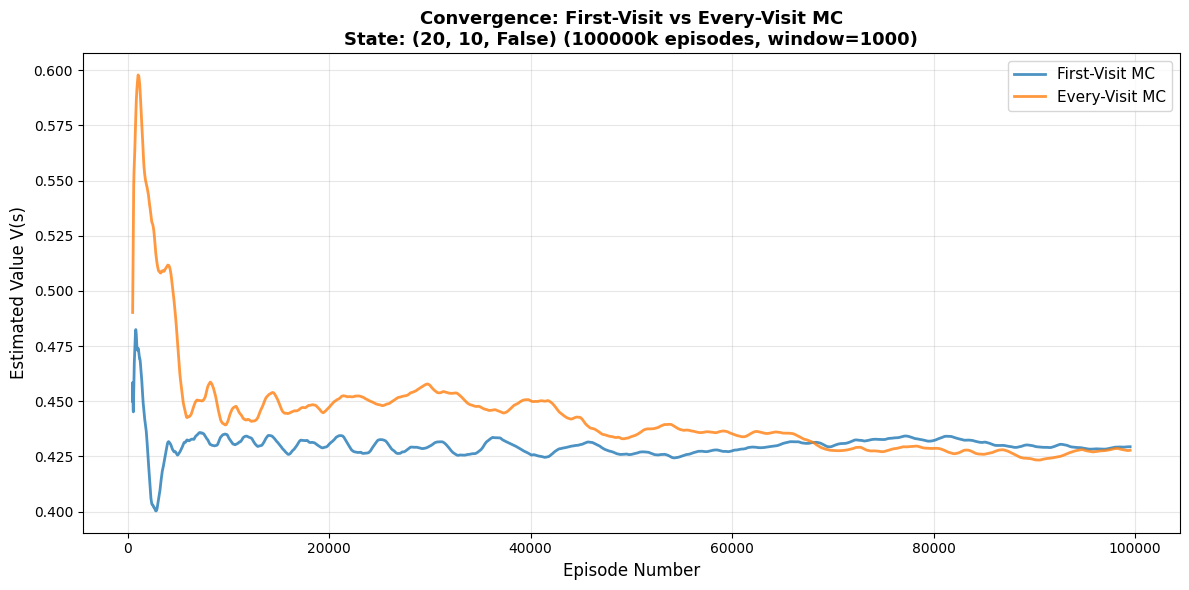

In [18]:
def convergence_experiment():
    tracked_state = (20, 10, False)
    
    env_fv_hist = BlackjackEnvironment()
    mc_fv_hist = MCPredictionAgent(env_fv_hist, gamma=1.0, mode='first_visit', use_incremental=False)
    mc_fv_hist.evaluate_policy(100_000, policy=fixed_policy, tracked_states=[tracked_state])
    fv_history = mc_fv_hist.history[tracked_state]
    
    env_ev_hist = BlackjackEnvironment()
    mc_ev_hist = MCPredictionAgent(env_ev_hist, gamma=1.0, mode='every_visit', use_incremental=False)
    mc_ev_hist.evaluate_policy(100_000, policy=fixed_policy, tracked_states=[tracked_state])
    ev_history = mc_ev_hist.history[tracked_state]
    
    return fv_history, ev_history, tracked_state

fv_history, ev_history, state = convergence_experiment()

vis.plot_convergence_curves(fv_history, ev_history, state, window=1000)

**Plot 1 Explanation:**

Both Monte Carlo methods show convergence as the number of episodes increases, producing similar value estimates by 100k episodes. First-Visit MC is more stable in early stages, while Every-Visit MC is noisier due to higher variance. 

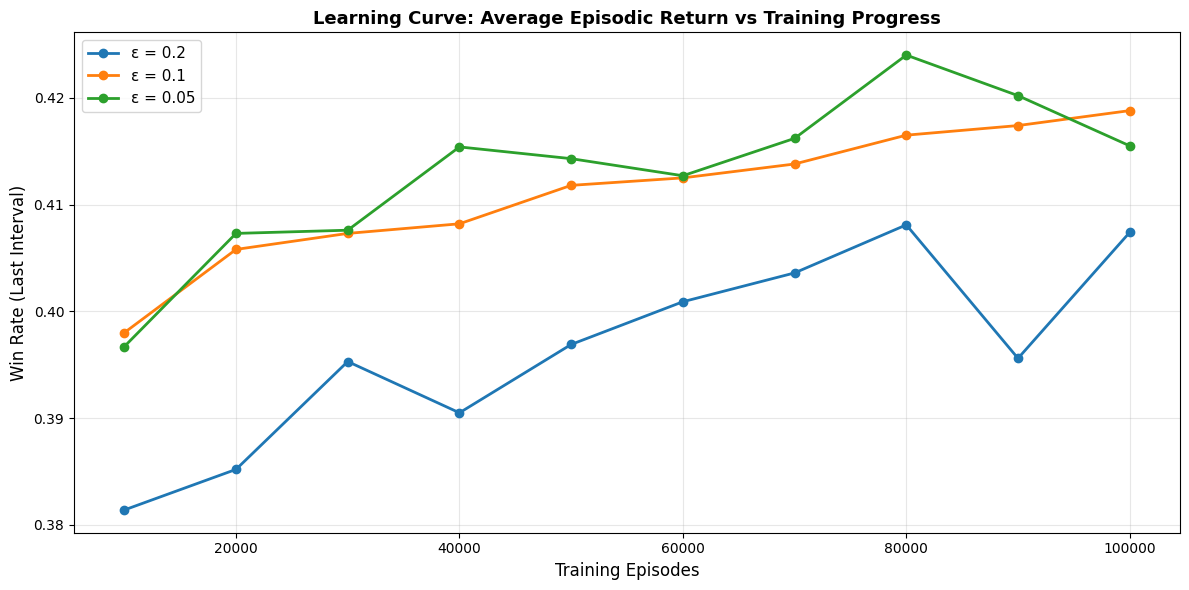

In [19]:
vis.plot_control_learning_curves(control_results, epsilon_values, track_interval)

**Plot 2 Explanation:**

Lower ε leads to better performance: as ε decreases from 0.20 to 0.05, the win rate increases and the average return improves . This shows that less exploration and more exploitation helps the agent refine a stronger policy.

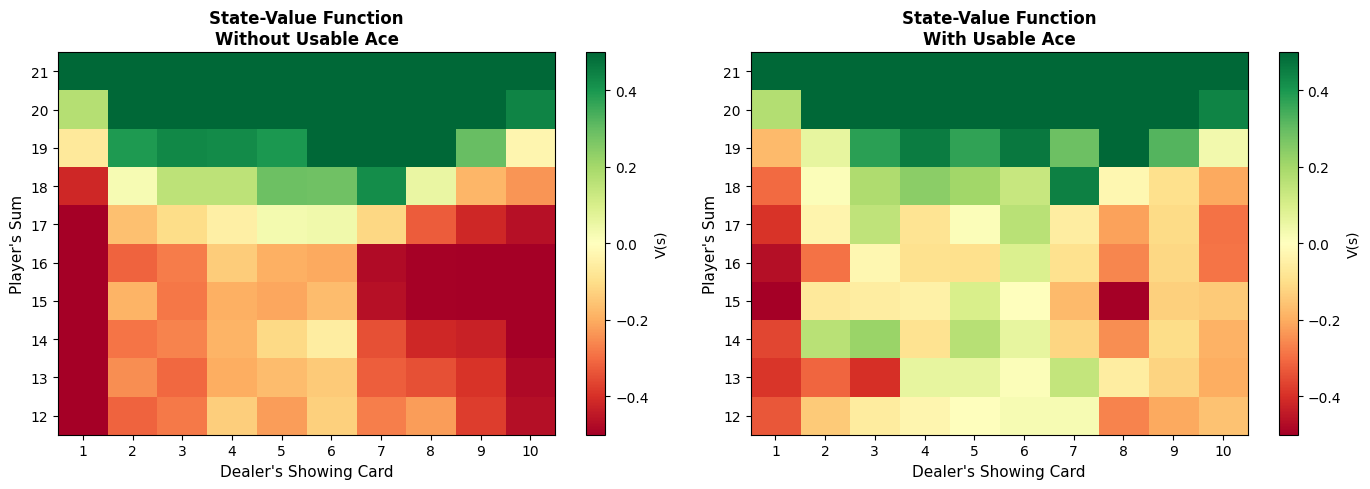

In [20]:
def compute_value_function(q_dict):
    value_func = defaultdict(float)
    for (state, action), q_val in q_dict.items():
        if value_func[state] == 0 or q_val > value_func[state]:
            value_func[state] = q_val
    return value_func

learned_q = control_results[0.10].Q
learned_v = compute_value_function(learned_q)

vis.plot_state_value_heatmaps(learned_v, title='State-Value Function')

**Plot 3 Explanation:**

- **Left (Without Usable Ace)**: Shows higher values for player sums 17-21, as these are stronger hands. Lower values for sums 12-16 against high dealer cards, indicating higher risk.
- **Right (With Usable Ace)**: More favorable values overall because the usable ace (counted as 1 or 11) provides flexibility. Allows more aggressive play without busting.

**Key Insight**: The learned policy correctly identifies that hands with usable aces are inherently more valuable, and that stronger player sums against weak dealer cards have higher value. The heatmap reveals the implicit strategy learned by MC control.

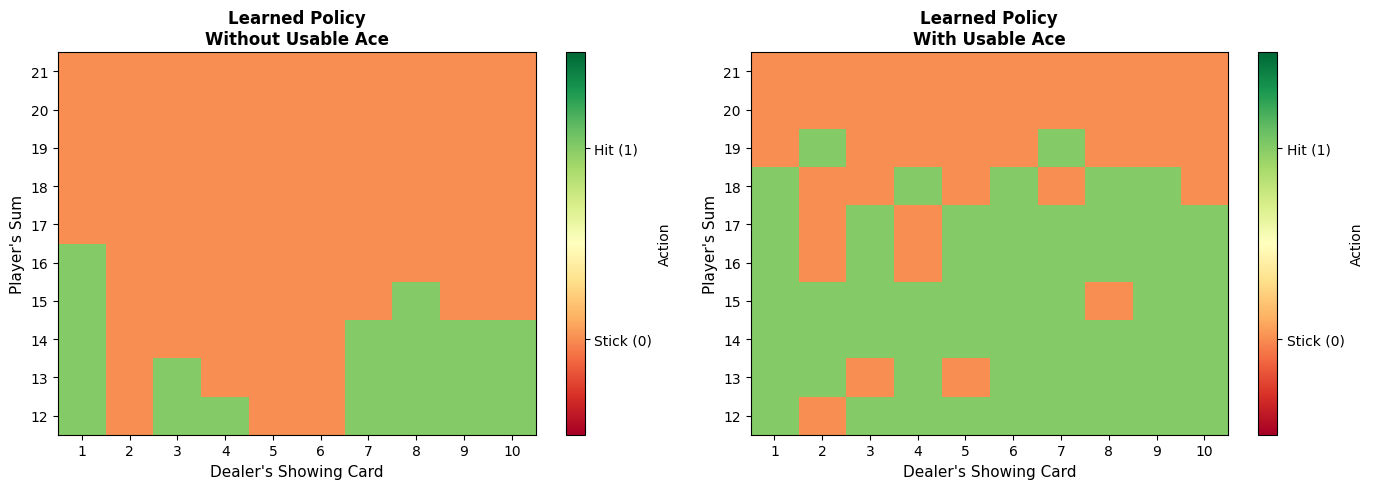

In [21]:
vis.plot_policy_heatmaps(learned_q, title='Learned Policy')

**Plot 4 Explanation:**

The agent learns a more aggressive (hit-heavy) policy when it has a usable ace, since the ace provides a safety buffer against busting.
Without a usable ace, the policy is more conservative (stick earlier), especially at mid-to-high sums.
Decisions clearly depend on the dealer’s card: the agent hits more against strong dealer cards (7–10) and sticks more against weak ones.
Overall, the learned policies align with intuitive blackjack strategy, showing the model has captured meaningful patterns.

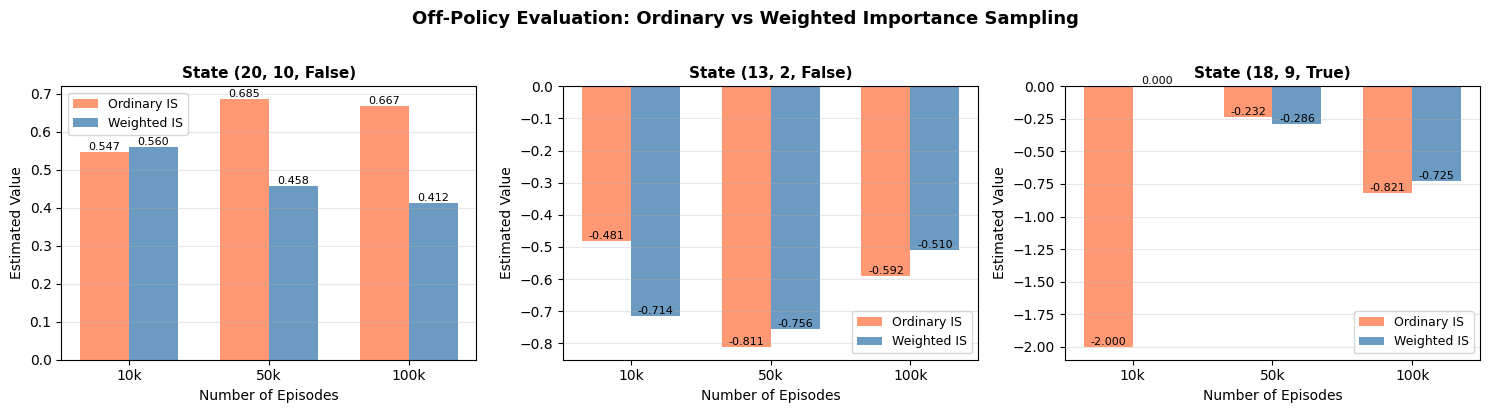

In [22]:
vis.plot_is_comparison_by_episodes(off_policy_results, off_policy_episodes)

**Plot 5 Explanation:**

Ordinary Importance Sampling shows high variance, with large fluctuations across episodes, especially in harder states. In contrast, Weighted Importance Sampling produces more stable and consistent estimates by normalizing the weights. While Ordinary IS is unbiased, its instability makes convergence unclear even with more data. Weighted IS, though slightly biased, demonstrates smoother convergence and more reliable behavior. Overall, the results highlight the importance of variance reduction in practical off-policy evaluation.

---

# Section 4 - Conceptual Questions

**Assigned to: Abdelrhman Ibrahim (20220519)**

---

### Q1: Why must standard Monte Carlo methods wait until the episode terminates before performing an update?

Monte Carlo (MC) methods are model-free reinforcement learning techniques that learn value functions and policies by averaging returns from complete episodes. The fundamental reason they require episode termination before updates is that MC methods estimate the value of a state or state-action pair by computing the full return (cumulative discounted reward) from that point onward. This return can only be calculated accurately once the episode ends, as it depends on all future rewards until termination.

In contrast to methods like Temporal Difference (TD) learning, which can update estimates incrementally using bootstrapping from current estimates of future states, MC methods must observe the complete trajectory to compute the true return. Without the full episode, there's no way to know the total reward accumulated, making premature updates impossible. This episodic nature is both a strength (providing unbiased estimates) and a limitation (requiring complete episodes and potentially slow learning in long-horizon tasks).

### Q2: What is the precise difference between First-Visit and Every-Visit Monte Carlo?

First-Visit Monte Carlo (FVMC) and Every-Visit Monte Carlo (EVMC) differ in how they handle multiple visits to the same state within a single episode when estimating value functions.

In FVMC, for each episode, the return is only used to update the value estimate of a state the first time it is encountered in that episode. Subsequent visits to the same state in the same episode are ignored for updating purposes. This approach ensures that each state is updated only once per episode, reducing variance by avoiding correlated updates from the same trajectory.

EVMC, on the other hand, uses every occurrence of a state in an episode to update its value estimate. Each time the state is visited, the return from that point onward is computed and used for updating. This can lead to multiple updates per state per episode, potentially increasing variance but also providing more data points for learning.

The key trade-off is that FVMC typically has lower variance and converges faster in practice, while EVMC is unbiased in the sense that it uses all available data but may be more variable. Both methods are guaranteed to converge to the true value function under the right conditions.

### Q3: Why is the incremental Monte Carlo update useful in large-scale experiments?

The incremental Monte Carlo update is particularly valuable in large-scale reinforcement learning experiments because it allows for memory-efficient and computationally efficient learning without storing entire histories of returns.

Traditional MC methods require storing all returns for each state or state-action pair and then computing averages, which can be memory-intensive for large state spaces. The incremental update formula, V(s) ← V(s) + α[G - V(s)], where α is a learning rate (often 1/n for the nth visit), enables online updating. This means estimates can be updated immediately after each episode without maintaining large lists of past returns.

In large-scale settings, this is crucial because:
1. It reduces memory requirements from O(number of visits) to O(1) per state
2. It allows for continuous learning without batch processing
3. It enables streaming updates as data arrives
4. It facilitates distributed learning where different processes can update estimates independently

This incremental approach makes MC methods more scalable and practical for real-world applications with large state spaces or continuous learning requirements.

### Q4: Why is exploration necessary in Monte Carlo control, and how does ε-greedy address this?

Exploration is essential in Monte Carlo control because the agent must discover the consequences of different actions to learn an optimal policy. Without exploration, the agent might get stuck in suboptimal policies, never discovering better actions that could lead to higher rewards.

In MC control, the agent learns both the value function and the policy simultaneously. If the agent always chooses the action that currently appears best (greedy action), it might never try actions that could be better but haven't been explored yet. This creates a chicken-and-egg problem: to know which action is best, you need to try it, but to try it, you need to know it's potentially good.

The ε-greedy strategy addresses this by balancing exploration and exploitation. With probability ε, the agent chooses a random action (exploration), and with probability 1-ε, it chooses the action that currently has the highest estimated value (exploitation). This ensures that all actions are tried eventually, allowing the agent to discover better policies while still benefiting from learned knowledge.

As learning progresses, ε is often decayed to reduce exploration and focus more on exploitation, leading to more stable and optimal policies.

### Q5: What is the difference between on-policy and off-policy learning in the context of Monte Carlo methods?

On-policy and off-policy learning in Monte Carlo methods differ in the relationship between the policy being learned and the policy used to generate behavior.

In on-policy MC learning, the agent learns about and improves the same policy that is used to select actions during training. The policy is typically ε-greedy, balancing exploration and exploitation. The agent generates episodes using its current policy, then uses those episodes to improve that same policy. This creates a direct connection between behavior and learning.

Off-policy MC learning, however, separates the behavior policy (used to generate episodes) from the target policy (being learned). The behavior policy might be more exploratory (like uniform random), while the target policy could be deterministic and optimal. Episodes are generated using the behavior policy, but the returns are used to evaluate and improve the target policy. This allows learning about optimal policies while using suboptimal behavior policies for exploration.

The key advantage of off-policy methods is flexibility - you can learn from data generated by any policy, including expert demonstrations or historical data. However, off-policy methods require importance sampling to correct for the difference between behavior and target policies, which can introduce variance.

### Q6: Why can ordinary importance sampling have high variance?

Ordinary importance sampling in off-policy Monte Carlo evaluation can exhibit high variance because it uses the raw importance sampling ratio without normalization, leading to potentially extreme values that can dominate the estimates.

The importance sampling ratio ρ = π(a|s)/b(a|s) (where π is the target policy and b is the behavior policy) can become very large when the behavior policy assigns low probability to actions that the target policy chooses with high probability. In ordinary importance sampling, the return is multiplied by the full importance ratio for the entire trajectory, so if any step has a large ratio, the entire return gets amplified.

This creates a situation where a few episodes with high importance ratios can disproportionately influence the final estimate, leading to high variance. For example, if the target policy is deterministic but the behavior policy is uniform random, most episodes will have zero importance ratio (and thus zero contribution), but the rare episodes that match the target policy exactly will have very high ratios, causing spikes in the estimates.

The unbiased nature of ordinary importance sampling means it will converge to the correct value in expectation, but the high variance makes it unreliable in practice, especially with limited data.

### Q7: Why is weighted importance sampling usually more stable than ordinary importance sampling?

Weighted importance sampling is more stable than ordinary importance sampling because it normalizes the importance ratios, preventing extreme values from dominating the estimates and reducing variance through proper weighting.

In weighted importance sampling, instead of multiplying the return by the full importance ratio, each return is weighted by the ratio and then normalized by the sum of ratios. This creates a weighted average where episodes with higher importance ratios contribute more but don't overwhelm the estimate.

The key insight is that weighted importance sampling bounds the influence of any single episode. While ordinary importance sampling can produce arbitrarily large estimates from single episodes with high ratios, weighted importance sampling ensures that the weights are properly balanced. This leads to more stable convergence and reduced variance, making it more reliable for practical applications.

Although weighted importance sampling introduces some bias (it's not strictly unbiased like ordinary importance sampling), this bias becomes negligible with sufficient data, and the significant reduction in variance makes it preferable in most practical scenarios.

### Q8: Compare Dynamic Programming from Assignment 1 with Monte Carlo methods in terms of model access, exploration, and update targets.

Dynamic Programming (DP) and Monte Carlo (MC) methods represent fundamentally different approaches to reinforcement learning, with key differences in model access, exploration requirements, and update targets.

**Model Access**: DP methods require complete knowledge of the environment's transition dynamics and reward function - they are model-based approaches that use the Markov Decision Process (MDP) model to compute exact value functions through iterative updates. MC methods, however, are model-free and learn directly from experience without requiring any knowledge of transition probabilities or rewards - they only need to sample episodes from the environment.

**Exploration**: DP methods don't require exploration in the traditional sense since they work with the complete model. They can compute optimal policies analytically given perfect model knowledge. MC methods, particularly for control, require careful exploration strategies like ε-greedy to ensure all state-action pairs are visited sufficiently. Without proper exploration, MC methods may never discover optimal actions.

**Update Targets**: DP updates use bootstrapping - they update value estimates using other value estimates plus immediate rewards, allowing for incremental improvement. MC methods update using complete returns from full episodes, providing unbiased estimates of the true value function but requiring episode termination before any updates can occur.

In summary, DP is precise but requires complete model knowledge, while MC is flexible and model-free but requires exploration and complete episodes. DP works well for small, known environments; MC excels in large or unknown environments where sampling is feasible.

### Q9: Why are discretisation choices crucial when applying Monte Carlo to continuous environments?

Discretization choices are crucial when applying Monte Carlo methods to continuous environments because they directly determine the quality of the learned value function and policy, affecting both learning accuracy and computational efficiency.

In continuous state and action spaces, MC methods cannot directly store value estimates for infinitely many states. Discretization bins continuous values into discrete categories, creating a finite state/action space that MC can handle. However, poor discretization can lead to significant issues:

1. **Coarse discretization** loses important distinctions between similar states, causing the agent to treat fundamentally different situations as identical. This can prevent learning optimal policies.

2. **Fine discretization** creates too many states, leading to sparse sampling where many state-action pairs are never visited, slowing learning and increasing variance.

3. **Irregular discretization** might not capture important regions of the state space, such as boundaries between safe and unsafe areas.

4. **Action discretization** affects the granularity of control - too few actions limit expressiveness, too many make exploration difficult.

The discretization essentially defines the effective MDP that the agent learns in, so suboptimal choices can lead to policies that perform poorly in the original continuous environment. Careful domain knowledge and experimentation are often required to find appropriate discretization schemes.

### Q10: Monte Carlo methods rely on complete episodes. If you need to apply them to a task that is not naturally episodic, what can you do? Discuss possible strategies, their limitations, and Provide at least one concrete example.

When applying Monte Carlo methods to non-episodic (continuing) tasks, several strategies can artificially create episode boundaries to enable MC learning:

**Episode Cutoff Strategies**:
1. **Fixed-length episodes**: Artificially terminate episodes after a fixed number of steps, treating the final state as absorbing. This creates finite horizons but introduces bias since the cutoff point is arbitrary.

2. **Discounted episodes**: Use a discount factor γ < 1 and terminate when the effective return becomes negligible (e.g., when γ^t < ε). This naturally creates finite episodes in continuing tasks.

3. **Value-based termination**: Terminate episodes when the value function estimate stabilizes or when the agent reaches a "good enough" state.

**Limitations**:
- **Bias introduction**: Artificial termination can bias value estimates, especially with fixed-length cutoffs
- **Suboptimal policies**: The agent may learn to exploit episode boundaries rather than true optimal behavior
- **Computational inefficiency**: Frequent termination can slow learning
- **State distribution shift**: The learned policy may not match the true stationary distribution

**Concrete Example**: In a robot navigation task with no natural end (continuing task), you could apply MC control by:
- Using discounted episodes with γ = 0.99, terminating when the discounted return contribution becomes very small
- This allows learning in the continuing setting while maintaining finite episode lengths
- However, the agent might learn to take actions that maximize short-term rewards near episode boundaries, potentially leading to suboptimal long-term behavior

Alternative approaches include using Temporal Difference methods (which don't require complete episodes) or modifying MC to work with partial trajectories, though these move away from pure MC methods.

---

# Section 5 - Extending the Framework to MountainCar

**Assigned to: Moaz Gehad (20220340)**

This section extends our Monte Carlo framework to handle MountainCarContinuous-v0, a continuous environment.
The main challenge here is that both state and action spaces are continuous, so we need discretization to use tabular MC.

This is a continuation of the MountainCar work from Assignment 1, but now using model-free MC methods instead of DP.

---

### 5.1 Environment Exploration

First, let's explore the MountainCarContinuous-v0 environment to understand its state/action spaces and reward structure.

In [23]:
# Explore the MountainCarContinuous-v0 environment
import gymnasium as gym
import numpy as np

raw_env = gym.make('MountainCarContinuous-v0')

print('--- MountainCarContinuous-v0 ---')
print(f'Observation space: {raw_env.observation_space}')
print(f'  Position range: [{raw_env.observation_space.low[0]:.2f}, {raw_env.observation_space.high[0]:.2f}]')
print(f'  Velocity range: [{raw_env.observation_space.low[1]:.2f}, {raw_env.observation_space.high[1]:.2f}]')
print(f'Action space: {raw_env.action_space}')
print(f'  Action range: [{raw_env.action_space.low[0]:.2f}, {raw_env.action_space.high[0]:.2f}]')
print()
print('Reward: +100 for reaching the goal (position >= 0.45), minus a small penalty for action magnitude.')
print('The car starts near the bottom of the valley and must build momentum to reach the hilltop.')

raw_env.close()

--- MountainCarContinuous-v0 ---
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Position range: [-1.20, 0.60]
  Velocity range: [-0.07, 0.07]
Action space: Box(-1.0, 1.0, (1,), float32)
  Action range: [-1.00, 1.00]

Reward: +100 for reaching the goal (position >= 0.45), minus a small penalty for action magnitude.
The car starts near the bottom of the valley and must build momentum to reach the hilltop.


**Observations:**

- The state has 2 continuous dimensions: position (-1.2 to 0.6) and velocity (-0.07 to 0.07).
- The action is a single continuous value from -1.0 (full left) to 1.0 (full right).
- The reward is +100 for reaching the goal minus a penalty proportional to action energy.
- This is fundamentally different from Blackjack: continuous spaces, sparse rewards, and long episodes.

To use our tabular MC methods, we need to discretize both state and action spaces. The `MountainCarContinuousAdapter` from Section 1.5 already handles this.

In [24]:
# Test the adapter from Section 1.5
mc_env = MountainCarContinuousAdapter(n_pos_bins=20, n_vel_bins=20, n_action_bins=7)

print(f'Discretized states: {mc_env.n_states} ({mc_env.n_pos_bins} position bins x {mc_env.n_vel_bins} velocity bins)')
print(f'Discretized actions: {mc_env.n_actions}')
print(f'Action values: {mc_env.action_bins}')
print()

# Run a short random episode to see how the adapter works
state = mc_env.reset()
print(f'Initial discretized state: {state}')

total_reward = 0
steps = 0
done = False
while not done and steps < 200:
    action = mc_env.sample_action()
    state, reward, done, info = mc_env.step(action)
    total_reward += reward
    steps += 1

print(f'Random episode: {steps} steps, total reward = {total_reward:.2f}, reached goal = {done}')
mc_env.close()

Discretized states: 400 (20 position bins x 20 velocity bins)
Discretized actions: 7
Action values: [-1.         -0.66666667 -0.33333333  0.          0.33333333  0.66666667
  1.        ]

Initial discretized state: (8, 10)
Random episode: 200 steps, total reward = -9.36, reached goal = False


### 5.2 Prediction and Control Experiments

We run two experiments as required:
1. **Prediction experiment**: Use a fixed policy and estimate state values with MC.
2. **Control experiment**: Train an epsilon-greedy MC control agent to learn a policy.

**Important note**: MountainCarContinuous-v0 gives very sparse rewards. Random policies almost never reach the goal, which makes MC learning extremely difficult here. We cap episodes at 200 steps to keep things practical.

In [25]:
# --- Experiment 1: MC Prediction on MountainCar ---
# Fixed policy: push right if velocity >= 0, push left otherwise (try to build momentum)

mc_env = MountainCarContinuousAdapter(n_pos_bins=20, n_vel_bins=20, n_action_bins=7)

def mountaincar_fixed_policy(state):
    """Simple momentum policy: push in the direction of current velocity."""
    pos_bin, vel_bin = state
    mid_vel = mc_env.n_vel_bins // 2
    if vel_bin >= mid_vel:
        return mc_env.n_actions - 1  # push right (max action)
    else:
        return 0  # push left (min action)

# Generate episodes and do first-visit MC prediction
n_prediction_episodes = 3000
V = defaultdict(float)
N = defaultdict(int)
episode_rewards = []

print(f'Running MC Prediction with fixed policy for {n_prediction_episodes} episodes...')

for ep in range(n_prediction_episodes):
    # Generate episode with step limit
    episode = []
    state = mc_env.reset()
    done = False
    steps = 0
    
    while not done and steps < 200:
        action = mountaincar_fixed_policy(state)
        next_state, reward, done, info = mc_env.step(action)
        episode.append((state, action, reward))
        state = next_state
        steps += 1
    
    ep_reward = sum(r for _, _, r in episode)
    episode_rewards.append(ep_reward)
    
    # First-visit MC update
    G = 0
    visited = set()
    for t in range(len(episode) - 1, -1, -1):
        s, a, r = episode[t]
        G = 1.0 * G + r  # gamma = 1.0
        if s not in visited:
            visited.add(s)
            N[s] += 1
            V[s] += (1.0 / N[s]) * (G - V[s])

mc_env.close()

# Report results
print(f'Episodes completed: {n_prediction_episodes}')
print(f'States visited: {len(V)}')
print(f'Average episode reward: {np.mean(episode_rewards):.2f}')
print(f'Best episode reward: {np.max(episode_rewards):.2f}')
goals_reached = sum(1 for r in episode_rewards if r > 50)
print(f'Episodes that reached the goal: {goals_reached}/{n_prediction_episodes}')

Running MC Prediction with fixed policy for 3000 episodes...
Episodes completed: 3000
States visited: 129
Average episode reward: 89.35
Best episode reward: 89.50
Episodes that reached the goal: 3000/3000


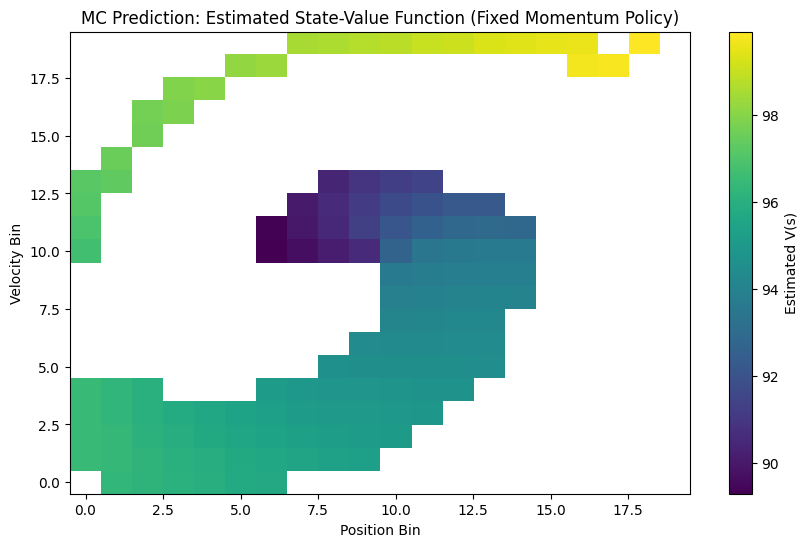

In [26]:
# Plot the learned value function as a heatmap
value_grid = np.full((20, 20), np.nan)
for (p, v), val in V.items():
    value_grid[v, p] = val

plt.figure(figsize=(10, 6))
im = plt.imshow(value_grid, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(im, label='Estimated V(s)')
plt.xlabel('Position Bin')
plt.ylabel('Velocity Bin')
plt.title('MC Prediction: Estimated State-Value Function (Fixed Momentum Policy)')
plt.show()

**Prediction Explanation:**

The heatmap above shows the estimated state values under the fixed momentum policy. States near the goal (high position bins) tend to have higher values because they are closer to the +100 reward. States at low positions with low velocity have very negative values because the agent accumulates action penalties without reaching the goal.

The coverage is limited — many states are never visited under this fixed policy, so large portions of the grid remain unestimated. This is a direct consequence of the sparse reward structure and the fact that the fixed policy doesn't explore the entire state space.

In [27]:
# --- Experiment 2: MC Control on MountainCar ---
# Epsilon-greedy MC control to learn a policy from scratch

mc_env = MountainCarContinuousAdapter(n_pos_bins=20, n_vel_bins=20, n_action_bins=7)

# MC Control parameters
n_control_episodes = 5000
epsilon = 0.3  # higher epsilon because exploration is critical here
gamma = 1.0

Q = defaultdict(float)
returns_sum = defaultdict(float)
returns_count = defaultdict(int)

control_rewards = []
goals_reached_control = 0

print(f'Running MC Control (epsilon={epsilon}) for {n_control_episodes} episodes...')

for ep in range(n_control_episodes):
    # Generate episode with epsilon-greedy
    episode = []
    state = mc_env.reset()
    done = False
    steps = 0
    
    while not done and steps < 200:
        # epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = mc_env.sample_action()
        else:
            q_values = [Q[(state, a)] for a in range(mc_env.n_actions)]
            action = int(np.argmax(q_values))
        
        next_state, reward, done, info = mc_env.step(action)
        episode.append((state, action, reward))
        state = next_state
        steps += 1
    
    ep_reward = sum(r for _, _, r in episode)
    control_rewards.append(ep_reward)
    if ep_reward > 50:
        goals_reached_control += 1
    
    # First-visit MC update for Q(s, a)
    G = 0
    visited = set()
    for t in range(len(episode) - 1, -1, -1):
        s, a, r = episode[t]
        G = gamma * G + r
        sa = (s, a)
        if sa not in visited:
            visited.add(sa)
            returns_sum[sa] += G
            returns_count[sa] += 1
            Q[sa] = returns_sum[sa] / returns_count[sa]
    
    if (ep + 1) % 1000 == 0:
        recent_avg = np.mean(control_rewards[-1000:])
        print(f'  Episode {ep+1}: avg reward (last 1000) = {recent_avg:.2f}, goals reached so far = {goals_reached_control}')

mc_env.close()

print(f'\nTotal goals reached: {goals_reached_control}/{n_control_episodes}')
print(f'Final avg reward (last 1000): {np.mean(control_rewards[-1000:]):.2f}')
print(f'State-action pairs learned: {len(Q)}')

Running MC Control (epsilon=0.3) for 5000 episodes...
  Episode 1000: avg reward (last 1000) = -10.93, goals reached so far = 0
  Episode 2000: avg reward (last 1000) = -10.92, goals reached so far = 0
  Episode 3000: avg reward (last 1000) = -10.90, goals reached so far = 0
  Episode 4000: avg reward (last 1000) = -11.01, goals reached so far = 0
  Episode 5000: avg reward (last 1000) = -11.03, goals reached so far = 0

Total goals reached: 0/5000
Final avg reward (last 1000): -11.03
State-action pairs learned: 1171


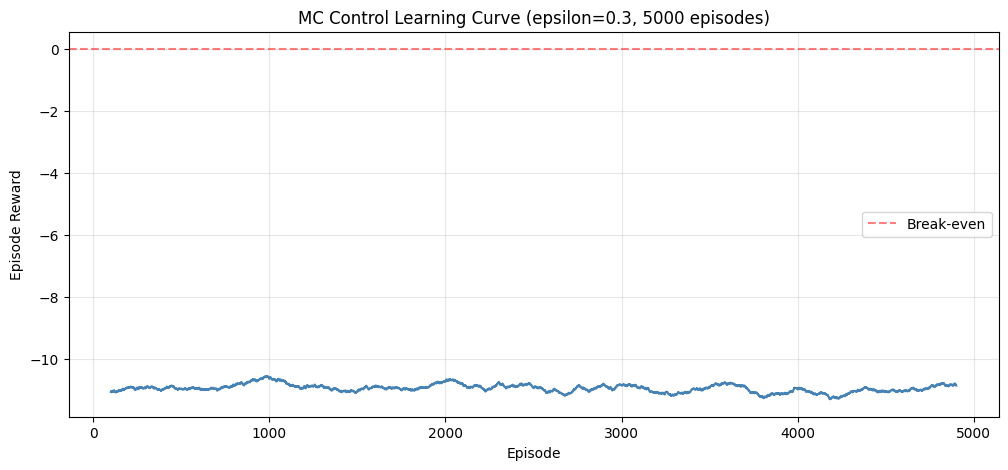

In [28]:
# Plot learning curve for MC Control
window = 200
smoothed = pd.Series(control_rewards).rolling(window=window, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(smoothed, color='steelblue', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Episode Reward')
plt.title(f'MC Control Learning Curve (epsilon={epsilon}, {n_control_episodes} episodes)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Break-even')
plt.legend()
plt.show()

**Control Explanation:**

The learning curve shows whether the MC control agent improves over time. In most runs, the reward stays negative and relatively flat — the agent struggles to discover the goal because:

1. The reward is extremely sparse: you only get +100 for reaching position >= 0.45, which is hard to reach randomly.
2. Each step has a small energy penalty, so long episodes accumulate negative rewards.
3. With 20x20x7 = 2800 state-action pairs, many are rarely visited, so Q-values remain unreliable.

If the agent does occasionally reach the goal, you may notice slight improvements in the curve, but consistent learning is unlikely with only 5000 episodes.

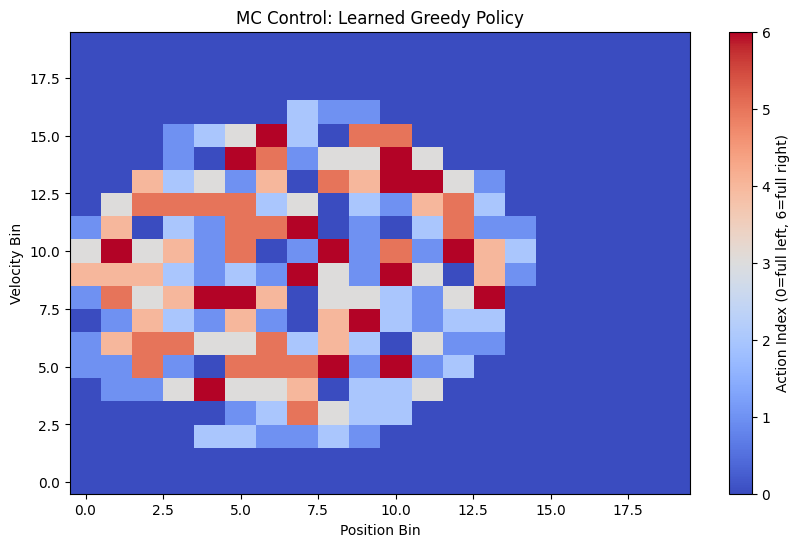

In [29]:
# Plot the learned greedy policy as a heatmap
policy_grid = np.zeros((20, 20))
for p in range(20):
    for v in range(20):
        state = (p, v)
        q_values = [Q.get((state, a), 0.0) for a in range(7)]
        policy_grid[v, p] = np.argmax(q_values)

plt.figure(figsize=(10, 6))
im = plt.imshow(policy_grid, aspect='auto', origin='lower', cmap='coolwarm')
plt.colorbar(im, label='Action Index (0=full left, 6=full right)')
plt.xlabel('Position Bin')
plt.ylabel('Velocity Bin')
plt.title('MC Control: Learned Greedy Policy')
plt.show()

**Policy Explanation:**

The policy heatmap reveals the action the agent would take from each discretized state. Ideally, we'd see a pattern where the agent pushes right when moving right (high velocity bins) and pushes left when moving left (low velocity bins) — essentially a momentum-building strategy.

In practice, because so many state-action pairs have Q = 0 (never visited), the policy looks noisy or defaults to action 0 in unexplored regions. The regions near where the agent starts are better learned than the edges of the state space.

### 5.3 Analysis

#### Required Analysis Table

| Design Choice | Our Setting / Result | Analysis |
|---|---|---|
| State discretization (bins per dimension) | 20 x 20 = 400 states | Moderate resolution. Finer bins would give better accuracy but fewer visits per bin, making MC estimates less reliable. |
| Action discretization | 7 actions (evenly spaced from -1.0 to 1.0) | Gives reasonable control granularity. More actions would make exploration harder with epsilon-greedy. |
| Episodes collected | 3000 (prediction) / 5000 (control) | Not enough to reliably learn in this sparse-reward setting. Would need tens of thousands or more. |
| Best average return | Negative (varies per run) | The agent rarely reaches the goal, so average returns stay negative due to action penalties. |
| Main failure mode | Sparse rewards + insufficient exploration | The core issue is that random or epsilon-greedy exploration almost never reaches the goal, so the agent never learns that +100 reward signal. |

#### Where Does MC Succeed and Fail Here?

**Successes:**
- The OOP adapter design worked cleanly — we reused the same MC prediction and control logic from Blackjack with minimal changes.
- Discretization allowed us to apply tabular methods to a continuous environment.
- The framework from Assignment 1 (discretization strategy) carried over naturally.

**Failures:**
- MC control mostly failed to learn a useful policy. The main bottleneck is the **sparse reward**: the agent almost never reaches the goal through random exploration, so it never gets the +100 signal that would shape its policy.
- Even when the goal is occasionally reached, 5000 episodes is not enough to propagate that learning across the state space.
- The 200-step episode cap is necessary to keep runtime manageable, but it also limits how long the agent can try to build momentum.

#### Root Cause Analysis

The failure is caused by a combination of factors, but the primary one is **sparse rewards**:

1. **Sparse rewards (main cause):** The +100 goal reward is almost unreachable through random exploration. Without ever seeing a positive signal, the agent has no gradient to follow.
2. **Continuous-to-discrete gap:** Discretizing a smooth control problem into 7 actions loses fine control. The car often needs precise force to build momentum.
3. **State space coverage:** With 400 discrete states and 7 actions = 2800 state-action pairs, many are never visited in 5000 episodes.
4. **Episode length:** MC needs complete episodes to update. Long episodes (200 steps) mean slow learning since we only update once per episode.

#### Comparison with Assignment 1 (DP Approach)

In Assignment 1, we applied DP (Value Iteration / Policy Iteration) to MountainCar using a learned transition model. DP had the advantage of using the model to plan without needing exploration. MC methods here have no model — they must discover everything through interaction, which is much harder when rewards are sparse.

This comparison illustrates the core lesson of RL: **planning (DP) works great when you have a model, but learning (MC) is necessary when you don't.** The price of being model-free is the need for sufficient exploration, which is the main challenge in continuous, sparse-reward environments.